# Preview: vessel-gap augmentation

Prototype for a SmallENet augmentation meant to teach the network to connect
gaps: pick a point along a vessel's *skeleton* (so both sides are guaranteed
to be well-defined vessel, not background or a bifurcation), reduce contrast
by ~30-40% in a small block around that point (input image only), and leave
the *label* untouched.

The label stays fully connected on purpose -- the augmentation makes the
input harder without changing the training target, which is what forces the
network to learn to predict connectivity through locally low-evidence image
regions instead of just tracing visible contrast. Contrast is *reduced*, not
wiped out and not blurred -- every pixel's deviation from the local
background mean is attenuated by `drop_frac`, no neighboring pixels mixed
in.

This notebook only previews the transform on a handful of patches from
`Dataset502_ARCADE_6x6_1c` -- nothing here is wired into training yet. The
"GT w/ gap" panel below is for visual reference only (to show where the
corrupted block actually sits relative to the vessel); it is never used as a
training target.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage as ndi
from skimage.morphology import skeletonize

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "dataset-prep" else Path.cwd()
IMAGES_TR = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset502_ARCADE_6x6_1c" / "imagesTr"
LABELS_TR = REPO_ROOT / "data" / "nnUNet_raw" / "Dataset502_ARCADE_6x6_1c" / "labelsTr"

rng = np.random.default_rng(0)

## Core functions: skeleton -> segments -> cut point -> corruption

1. `skeleton_degree` -- neighbor count per skeleton pixel (1 = tip, 2 =
   vessel body, >=3 = bifurcation).
2. `extract_segments` -- strip bifurcation pixels, connected-component the
   remainder, order each component into a walk from one end to the other.
   Each resulting segment is a clean, unbranched vessel run between two
   "nodes" (tips or bifurcations) -- exactly what we want to cut in the
   middle of.
3. `pick_cut_point` -- an index into a segment's walk, kept `margin` pixels
   away from both ends so the two resulting stumps are unambiguously
   well-defined vessel, not sliver remnants.
4. `corrupt_patch` -- flattens (or blurs) a block sized from the *local
   vessel radius* at the cut point, so thick and thin vessels both get fully
   occluded rather than using one fixed block size for everything.

In [2]:
def skeleton_degree(skel: np.ndarray) -> np.ndarray:
    kernel = np.ones((3, 3), dtype=int)
    neighbor_count = ndi.convolve(skel.astype(int), kernel, mode="constant") - skel.astype(int)
    return neighbor_count * skel


def _order_path(component_mask: np.ndarray) -> list[tuple[int, int]]:
    """Walk a simple (unbranched) skeleton component end to end."""
    coords = set(map(tuple, np.argwhere(component_mask)))
    deg = {
        p: sum((p[0] + dy, p[1] + dx) in coords for dy in (-1, 0, 1) for dx in (-1, 0, 1) if (dy, dx) != (0, 0))
        for p in coords
    }
    endpoints = [p for p, d in deg.items() if d == 1]
    start = endpoints[0] if endpoints else next(iter(coords))
    path, visited, cur = [start], {start}, start
    while len(path) < len(coords):
        nxt = None
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                if dy == 0 and dx == 0:
                    continue
                nb = (cur[0] + dy, cur[1] + dx)
                if nb in coords and nb not in visited:
                    nxt = nb
                    break
            if nxt is not None:
                break
        if nxt is None:
            break
        path.append(nxt)
        visited.add(nxt)
        cur = nxt
    return path


def extract_segments(skel: np.ndarray, min_length: int = 20) -> list[list[tuple[int, int]]]:
    """Bifurcation-free vessel runs, each ordered as a walk between its two ends."""
    deg = skeleton_degree(skel)
    trimmed = skel & (deg < 3)
    labeled, n = ndi.label(trimmed, structure=np.ones((3, 3)))
    segments = []
    for i in range(1, n + 1):
        comp = labeled == i
        if comp.sum() >= min_length:
            segments.append(_order_path(comp))
    return segments


def pick_cut_point(segment: list[tuple[int, int]], margin: int = 8) -> tuple[int, int]:
    if len(segment) < 2 * margin + 2:
        return segment[len(segment) // 2]
    idx = rng.integers(margin, len(segment) - margin)
    return segment[idx]


def corrupt_patch(
    image: np.ndarray,
    mask: np.ndarray,
    center: tuple[int, int],
    mode: str = "contrast_drop",
    drop_frac: float = 0.35,
    noise_std: float = 2.0,
) -> tuple[np.ndarray, tuple[int, int, int, int]]:
    radius = ndi.distance_transform_edt(mask)[center]
    half_width = max(3, int(round(radius)) + 2)
    y, x = center
    h, w = image.shape
    y0, y1 = max(0, y - half_width), min(h, y + half_width + 1)
    x0, x1 = max(0, x - half_width), min(w, x + half_width + 1)
    out = image.astype(np.float32).copy()
    bg = image[~mask]
    local_mean = bg.mean() if bg.size else image.mean()
    block = out[y0:y1, x0:x1]
    if mode == "contrast_drop":
        # Pull every pixel's deviation from the local background mean toward
        # zero by drop_frac -- e.g. drop_frac=0.35 leaves 65% of the original
        # contrast intact. This is a genuine contrast reduction, not a full
        # wipe (that's drop_frac=1.0, equivalent to the old "flatten" mode)
        # and not spatial blur -- no neighboring pixels are mixed in.
        out[y0:y1, x0:x1] = local_mean + (1 - drop_frac) * (block - local_mean)
    elif mode == "flatten":
        out[y0:y1, x0:x1] = local_mean + rng.normal(0, noise_std, size=block.shape)
    elif mode == "blur":
        pad = half_width + 2
        yp0, yp1 = max(0, y0 - pad), min(h, y1 + pad)
        xp0, xp1 = max(0, x0 - pad), min(w, x1 + pad)
        blurred = ndi.gaussian_filter(out[yp0:yp1, xp0:xp1], sigma=2.5)
        out[y0:y1, x0:x1] = blurred[y0 - yp0 : y1 - yp0, x0 - xp0 : x1 - xp0]
    else:
        raise ValueError(mode)
    return np.clip(out, 0, 255).astype(np.uint8), (y0, y1, x0, x1)


def gapped_gt_for_viz(mask: np.ndarray, box: tuple[int, int, int, int]) -> np.ndarray:
    """Visualization only -- never used as an actual training target."""
    y0, y1, x0, x1 = box
    out = mask.copy()
    out[y0:y1, x0:x1] = False
    return out


## Find eligible patches

A patch is eligible if it has at least one bifurcation-free skeleton segment
long enough to leave well-defined stumps on both sides of a cut. This is the
same kind of cheap, fully-automatic filter as the empty/non-empty bookkeeping
in `downsample_empty_patches.py` -- no manual labeling involved.

In [3]:
MIN_SEGMENT_LENGTH = 40  # >= 2*margin + a little slack

candidates = []
label_files = sorted(LABELS_TR.glob("train_1*_b*.png"))
for f in label_files[:3000]:
    arr = np.asarray(Image.open(f))
    if arr.ndim == 3:
        arr = arr[..., 0]
    mask = arr == 1
    if mask.sum() < MIN_SEGMENT_LENGTH:
        continue
    skel = skeletonize(mask)
    segments = extract_segments(skel, min_length=MIN_SEGMENT_LENGTH)
    if segments:
        candidates.append(f.stem)

print(f"{len(candidates)} eligible patches out of {min(3000, len(label_files))} scanned")
sample_cases = list(rng.choice(candidates, size=4, replace=False))
print("sample:", sample_cases)

845 eligible patches out of 2800 scanned
sample: ['train_12_b0404', 'train_154_b0300', 'train_185_b0400', 'train_166_b0103']


## Preview -- 35% contrast drop (no blur, no full wipe)

Each pixel's deviation from the local background mean is attenuated to 65%
of its original size inside the block. This keeps the block's own texture/
noise pattern intact (no neighboring pixels are mixed in, unlike blur) while
genuinely weakening the vessel's contrast cue -- not erasing it entirely
(that's `drop_frac=1.0`, the old "flatten" mode).

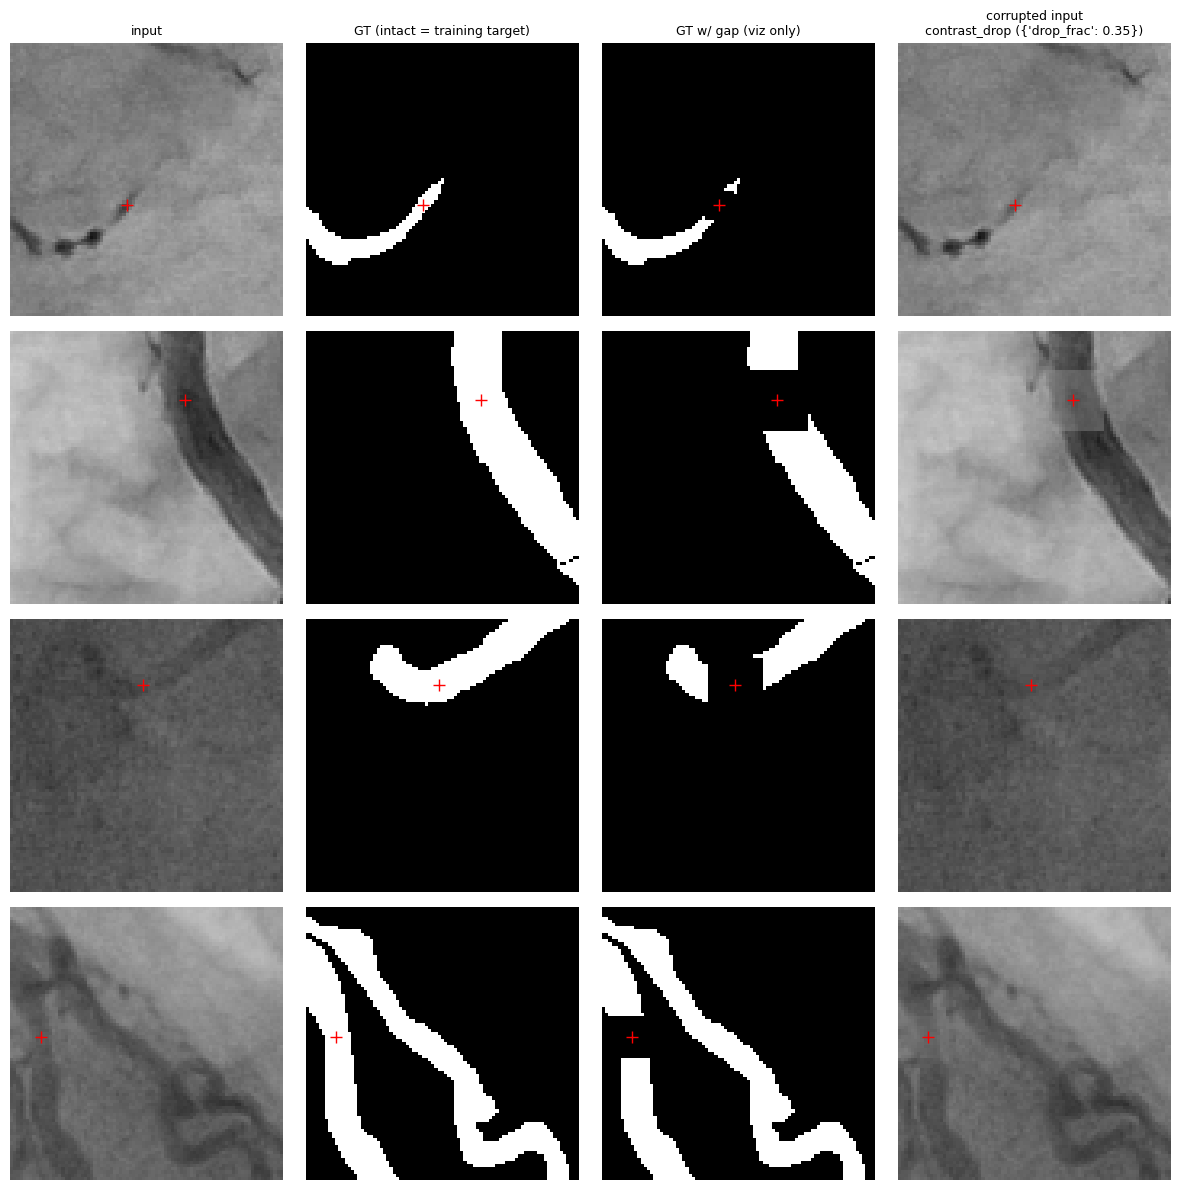

In [4]:
def preview_cases(case_ids: list[str], mode: str = "contrast_drop", **corrupt_kwargs) -> None:
    fig, axes = plt.subplots(len(case_ids), 4, figsize=(12, 3 * len(case_ids)))
    label = f"{mode} ({corrupt_kwargs})" if corrupt_kwargs else mode
    col_titles = ["input", "GT (intact = training target)", "GT w/ gap (viz only)", f"corrupted input\n{label}"]
    for row, case in enumerate(case_ids):
        img = np.asarray(Image.open(IMAGES_TR / f"{case}_0000.png"))
        lbl_arr = np.asarray(Image.open(LABELS_TR / f"{case}.png"))
        if lbl_arr.ndim == 3:
            lbl_arr = lbl_arr[..., 0]
        mask = lbl_arr == 1
        skel = skeletonize(mask)
        segments = extract_segments(skel, min_length=MIN_SEGMENT_LENGTH)
        segment = max(segments, key=len)
        center = pick_cut_point(segment, margin=8)
        corrupted_img, box = corrupt_patch(img, mask, center, mode=mode, **corrupt_kwargs)
        gapped = gapped_gt_for_viz(mask, box)

        panels = [img, mask, gapped, corrupted_img]
        for col, panel in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(panel, cmap="gray", vmin=0, vmax=255 if panel.dtype == np.uint8 and panel.max() > 1 else 1)
            ax.plot(center[1], center[0], "r+", markersize=8)
            ax.axis("off")
            if row == 0:
                ax.set_title(col_titles[col], fontsize=9)
        axes[row, 0].set_ylabel(case, fontsize=8)
    plt.tight_layout()
    plt.show()


preview_cases(sample_cases, mode="contrast_drop", drop_frac=0.35)

## Comparing drop strengths (same cut points, same cases)

Same cases and cut points as above, at 25% / 40% / 55% drop, to gauge how
much is "clearly weakened but still readable" vs. "basically gone."

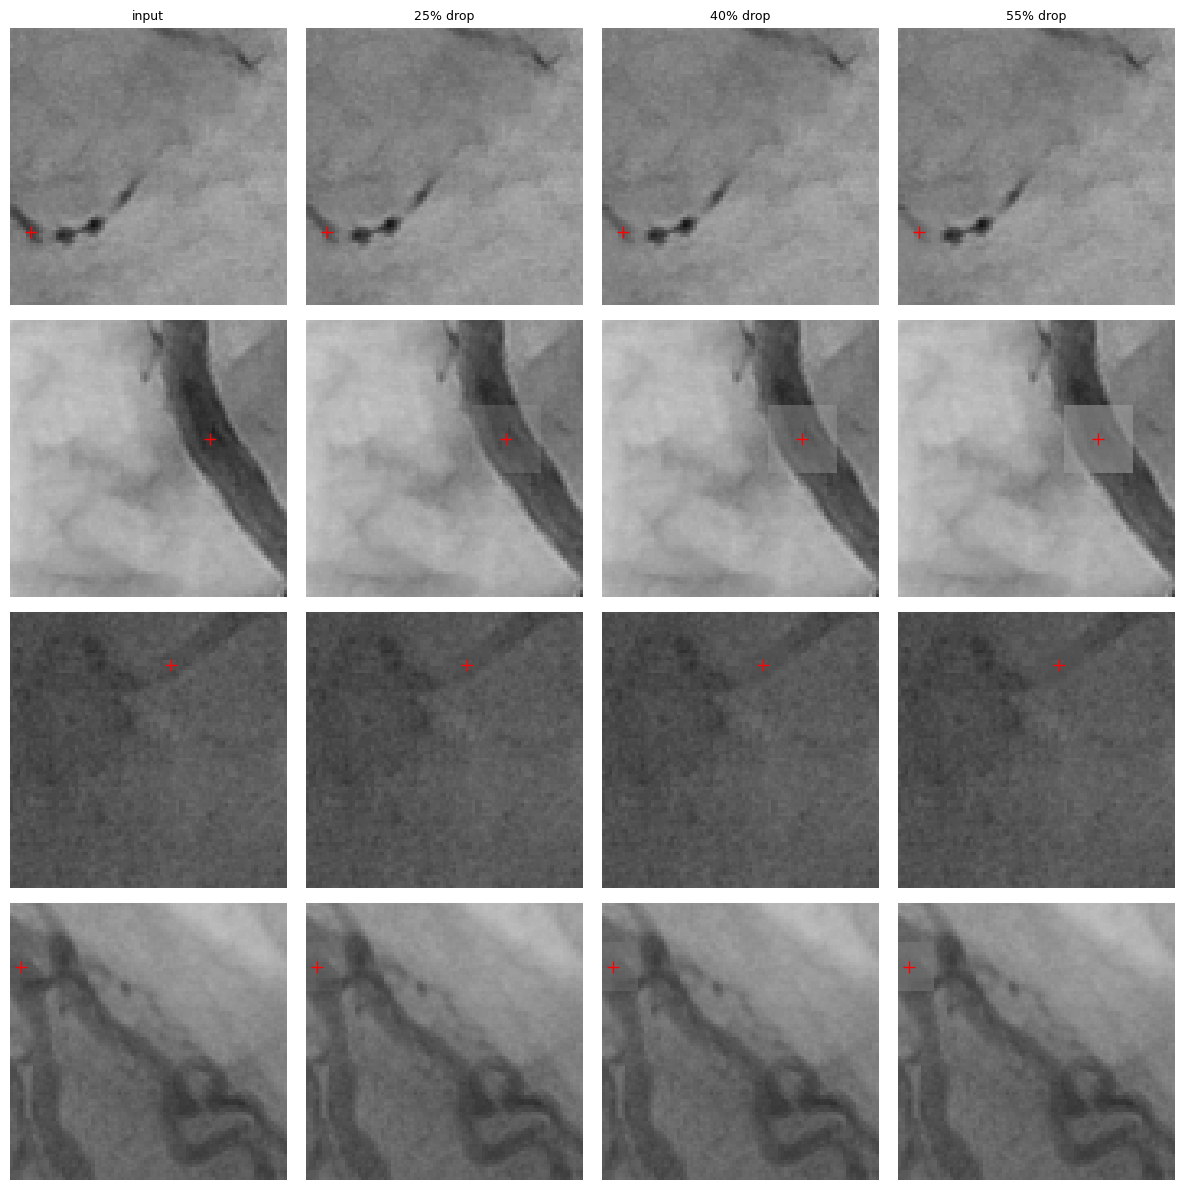

In [5]:
def preview_drop_strengths(case_ids: list[str], drop_fracs: list[float]) -> None:
    fig, axes = plt.subplots(len(case_ids), 1 + len(drop_fracs), figsize=(3 * (1 + len(drop_fracs)), 3 * len(case_ids)))
    col_titles = ["input"] + [f"{int(round(d * 100))}% drop" for d in drop_fracs]
    for row, case in enumerate(case_ids):
        img = np.asarray(Image.open(IMAGES_TR / f"{case}_0000.png"))
        lbl_arr = np.asarray(Image.open(LABELS_TR / f"{case}.png"))
        if lbl_arr.ndim == 3:
            lbl_arr = lbl_arr[..., 0]
        mask = lbl_arr == 1
        skel = skeletonize(mask)
        segments = extract_segments(skel, min_length=MIN_SEGMENT_LENGTH)
        segment = max(segments, key=len)
        center = pick_cut_point(segment, margin=8)  # same cut point reused for every drop_frac below

        axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=255)
        axes[row, 0].plot(center[1], center[0], "r+", markersize=8)
        axes[row, 0].axis("off")
        if row == 0:
            axes[row, 0].set_title(col_titles[0], fontsize=9)

        for col, drop_frac in enumerate(drop_fracs, start=1):
            corrupted_img, _ = corrupt_patch(img, mask, center, mode="contrast_drop", drop_frac=drop_frac)
            axes[row, col].imshow(corrupted_img, cmap="gray", vmin=0, vmax=255)
            axes[row, col].plot(center[1], center[0], "r+", markersize=8)
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(col_titles[col], fontsize=9)
    plt.tight_layout()
    plt.show()


preview_drop_strengths(sample_cases, drop_fracs=[0.25, 0.40, 0.55])

## Notes

- `contrast_drop` (attenuate deviation from local background mean, no
  spatial mixing) is the mode to use -- `flatten` (100% drop) erases the
  vessel entirely, and `blur` mixes in neighboring pixels rather than just
  reducing contrast in place. Both are still defined in `corrupt_patch` for
  reference but `contrast_drop` is the default.
- Eligibility (`extract_segments` returning >=1 long-enough segment) and
  cut-point sampling are both cheap (a few ms per 85x85-96x96 patch) -- fine
  to run live inside a `batchgenerators` transform per epoch rather than
  precomputing a fixed cut per patch. A fixed offline cut would let the
  network memorize "there's always a gap at (x, y) in this case," which
  defeats the purpose.
- Only the per-patch *eligibility* (does a long-enough segment exist at all)
  is worth precomputing/caching, mirroring `downsample_empty_patches.py`'s
  empty/non-empty bookkeeping -- purely so the transform can skip ineligible
  patches instantly instead of re-running skeletonize + component-labeling
  on every access just to find a no-op.
- Still open: what `drop_frac` to actually train with (30-40% was the ask;
  the strength comparison above should help pick a number), and whether to
  apply this transform on every batch or with some probability/schedule.